<a href="https://colab.research.google.com/github/joblingjack/Visual-Analytics/blob/main/BAN_304_Jobling_Python_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Python Project (15 points)


In this project, you will demonstrate your understanding of the Python programming concepts, modules, and commands we covered in class.

You must complete this **individually**- DO NOT work together or provide help to one another.

Use the packages and functions we reviewed in class to answer all questions in the Project.

Submit your pdf file on Canvas to recieve credit for the Python Project (or share the link via canvas). Please verify all items are visible in the pdf document. If I cannot see the output then I will not be able to grade that item and you will receive a reduction in points.

*An additional comment with the link to the project (with the setting allowing all who have the link can view) is recommended in the event items get cut off on the pdf.*

## **1. Libraries, Modules and Packages** (1 point)


Install and import the libraries, modules, and packages needed to complete your project.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

In [2]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/BAN 304/car_data.xlsx"
automobiles = pd.read_excel(file_path, sheet_name="Automobiles")
sales = pd.read_excel(file_path, sheet_name="SalesData")

Mounted at /content/drive


In [3]:
# Convert all character (object) columns to factors (category)
for col in automobiles.select_dtypes(include=['object']).columns:
    automobiles[col] = automobiles[col].astype('category')

# 1. Convert 'make' to a standard factor
sales['make'] = sales['make'].astype('category')

# 2. Convert 'day' to an ORDERED factor
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
ordered_days = CategoricalDtype(categories=day_order, ordered=True)

sales['day'] = sales['day'].astype(ordered_days)

automobiles.columns = automobiles.columns.str.lower().str.replace("-", "_")
sales.columns = sales.columns.str.lower().str.replace("-", "_")
cyl_order = ['two', 'three', 'four', 'five', 'six', 'eight', 'twelve']
cyl_type = CategoricalDtype(categories=cyl_order, ordered=True)

# 2. Apply to automobiles dataframe
automobiles['num_of_cylinders'] = automobiles['num_of_cylinders'].astype(cyl_type)

# Calculate total sales for each car make
total_sales_by_make = sales.groupby('make')['total_price'].sum().reset_index()

# Sort by total sales and get top 10
top_10_selling_makes = total_sales_by_make.sort_values(by='total_price', ascending=False)

/tmp/ipykernel_7642/3235089102.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_sales_by_make = sales.groupby('make')['total_price'].sum().reset_index()


## **2. Data** (2 points)

The dataset for this assignment includes car dealership sales transactions from March, April, and May 2026. It also provides information on the different vehicle types and the parts required for each. The workbook contains two worksheets, “Automobiles” and “SalesData.” You can access the file in Canvas under the title car_data.xlsx.

###Read-In Data
Read-in the excel file into two data frames.

Check the first 15 rows (observations) to verify the read-in completed successfully. Display the first 15 rows for each dataframe as output in this project.



In [4]:
display(automobiles.head(15))
display(sales.head(15))

,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,2548,dohc,four,130,mpfi,111,5000,21,27,13655.311859
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,2548,dohc,four,130,mpfi,111,5000,21,27,16365.124879
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,2823,ohcv,six,152,mpfi,154,5000,19,26,16638.683561
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,2337,ohc,four,109,mpfi,102,5500,24,30,13823.704868
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,2824,ohc,five,136,mpfi,115,5500,18,22,17424.480490
5,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,...,2507,ohc,five,136,mpfi,110,5500,19,25,15327.345742
6,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,...,2844,ohc,five,136,mpfi,110,5500,19,25,17808.582740
7,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,...,2954,ohc,five,136,mpfi,110,5500,19,25,18748.576534
8,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,...,3086,ohc,five,131,mpfi,140,5500,17,20,23964.088633
9,audi,gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,...,3053,ohc,five,131,mpfi,160,5500,16,22,22957.519827


,date,make,body_style,quantity_sold,unit_price,total_price,day
0,2026-03-01,bmw,sedan,8,16541.040582,132328.324654,Sunday
1,2026-03-01,toyota,hatchback,8,5509.931436,44079.451491,Sunday
2,2026-03-01,porsche,hatchback,6,22159.524166,132957.144995,Sunday
3,2026-03-01,porsche,hatchback,5,22159.524166,110797.620829,Sunday
4,2026-03-01,subaru,hatchback,3,5289.036289,15867.108867,Sunday
5,2026-03-01,volvo,sedan,4,12895.394232,51581.576928,Sunday
6,2026-03-01,mazda,hatchback,7,5133.592832,35935.149821,Sunday
7,2026-03-01,saab,hatchback,6,11963.010500,71778.063003,Sunday
8,2026-03-01,chevrolet,hatchback,7,5245.191330,36716.339307,Sunday
9,2026-03-01,toyota,hatchback,6,5509.931436,33059.588618,Sunday


### **3. Exploratory Data Analysis** **(4 points)**

The goal of this section is to conduct an exploratory data analysis (EDA) on the datasets to gain insights into the structure, relationships, and key patterns. The following items must be included for each dataframe:



*   Number of Variables and Number of Observations
*   Data Type for each Variable
*   Are there any missing data points?
*   Did any of the variables need to have the data type changed? If so, what did you change it to?
*   Provide summary measures for all variables (numerical and categorical)
* Visualizations are expected (a minimum of 2 boxplots and 2 histograms)


#Automobiles EDA

**Number of Variables and Number of Observations**

There are 205 observations and 21 variables

**Data Type for each Variable**

make: Factor

fuel-type: Factor

aspiration: Factor

num_of_doors: Factor

body_style: Factor

drive_wheels: Factor

engine_location: Factor

wheel_base: Numeric

length: Numeric

width: Numeric

height: Numeric

curb_weight: Numeric

engine_type: Factor

num_of_cylinders: Factor

engine_size: Numeric

fuel_system: Factor

horsepower: Numeric

peak_rpm: Numeric

city_mpg: Numeric

highway_mpg: Numeric

price: Numeric

**Are there any missing data points?**

There are no missing data points

**Did any of the variables need to have the data type changed? If so, what did you change it to?**

I changed all character data types into factor so they're easier to understand especially since its a cross-sectional dataset.

In [5]:
#Automobiles EDA
print(automobiles.shape)
print(automobiles.info())
print(automobiles.isna().sum())
print(automobiles.describe(include='all'))

(205, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   make              205 non-null    category
 1   fuel_type         205 non-null    category
 2   aspiration        205 non-null    category
 3   num_of_doors      205 non-null    category
 4   body_style        205 non-null    category
 5   drive_wheels      205 non-null    category
 6   engine_location   205 non-null    category
 7   wheel_base        205 non-null    float64 
 8   length            205 non-null    float64 
 9   width             205 non-null    float64 
 10  height            205 non-null    float64 
 11  curb_weight       205 non-null    int64   
 12  engine_type       205 non-null    category
 13  num_of_cylinders  205 non-null    category
 14  engine_size       205 non-null    int64   
 15  fuel_system       205 non-null    category
 16  horsepower      

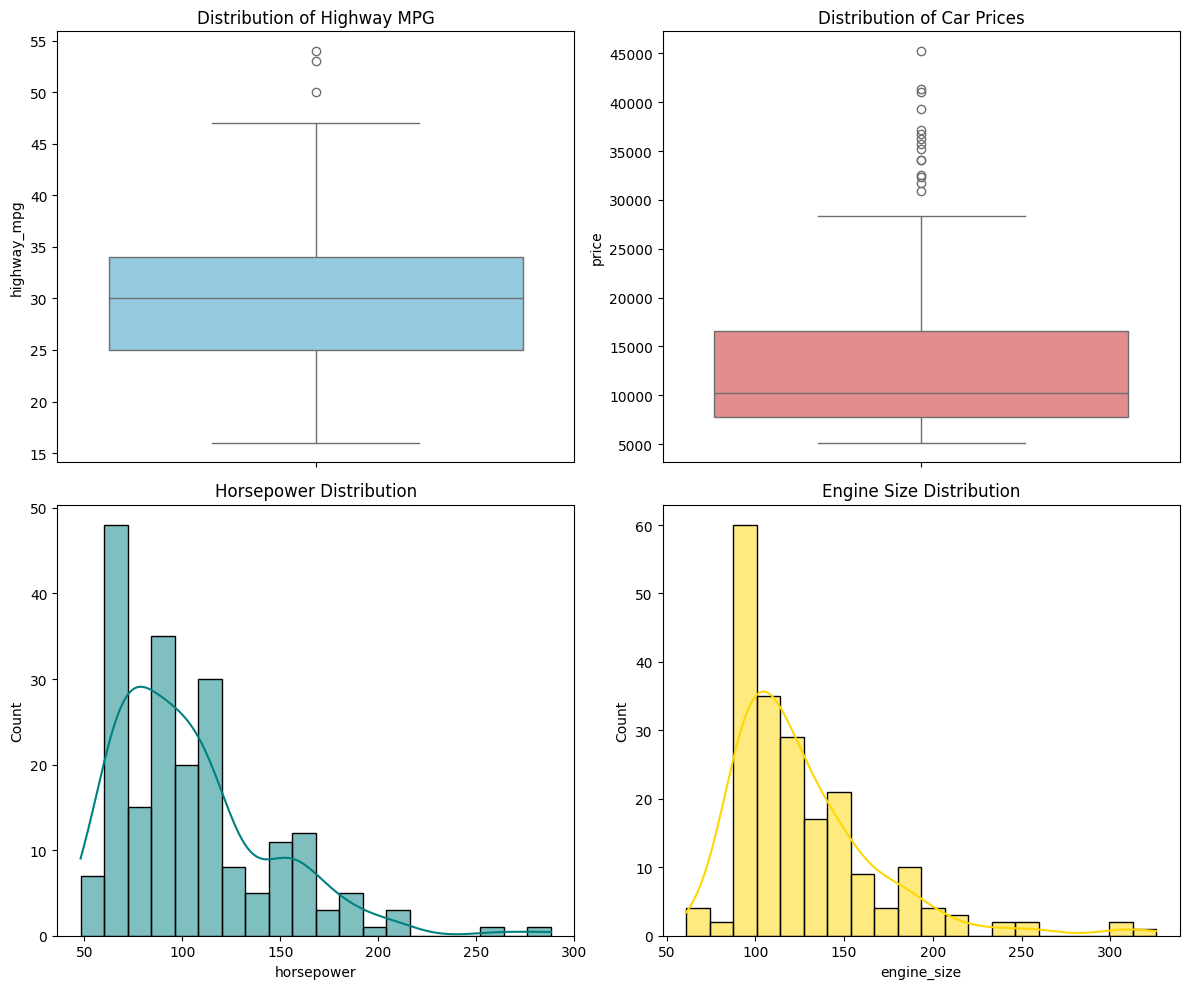

In [6]:
#Automobiles EDA
# Create a 2x2 grid of plots
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# 1. Top Left: Highway MPG Boxplot
sns.boxplot(y=automobiles['highway_mpg'], ax=ax[0, 0], color='skyblue')
ax[0, 0].set_title("Distribution of Highway MPG")

# 2. Top Right: Price Boxplot
sns.boxplot(y=automobiles['price'], ax=ax[0, 1], color='lightcoral')
ax[0, 1].set_title("Distribution of Car Prices")

# 3. Bottom Left: Horsepower Histogram
sns.histplot(automobiles['horsepower'], bins=20, ax=ax[1, 0], kde=True, color='teal')
ax[1, 0].set_title("Horsepower Distribution")

# 4. Bottom Right: Engine Size Histogram
sns.histplot(automobiles['engine_size'], bins=20, ax=ax[1, 1], kde=True, color='gold')
ax[1, 1].set_title("Engine Size Distribution")

plt.tight_layout()
plt.show()

#SalesData EDA

**Number of Variables and Number of Observations**

5000 observations and 7 variables

**Data Type for each Variable**

date: Date/Time

make: Factor

body_style: Character

quantity_sold: Numeric

unit_price: Numeric

total_price: Numeric

day: Factor

**Are there any missing data points?**

There are no missing data points

**Did any of the variables need to have the data type changed? If so, what did you change it to?**

I changed the days from a character to a factor so they order in the days of the week and make to factor.

In [7]:
print(sales.shape)
print(sales.info())
print(sales.isna().sum())
print(sales.describe(include='all'))

(5000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           5000 non-null   datetime64[ns]
 1   make           5000 non-null   category      
 2   body_style     5000 non-null   object        
 3   quantity_sold  5000 non-null   int64         
 4   unit_price     5000 non-null   float64       
 5   total_price    5000 non-null   float64       
 6   day            5000 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 206.3+ KB
None
date             0
make             0
body_style       0
quantity_sold    0
unit_price       0
total_price      0
day              0
dtype: int64
                              date    make body_style  quantity_sold  \
count                         5000    5000       5000    5000.000000   
unique                         NaN

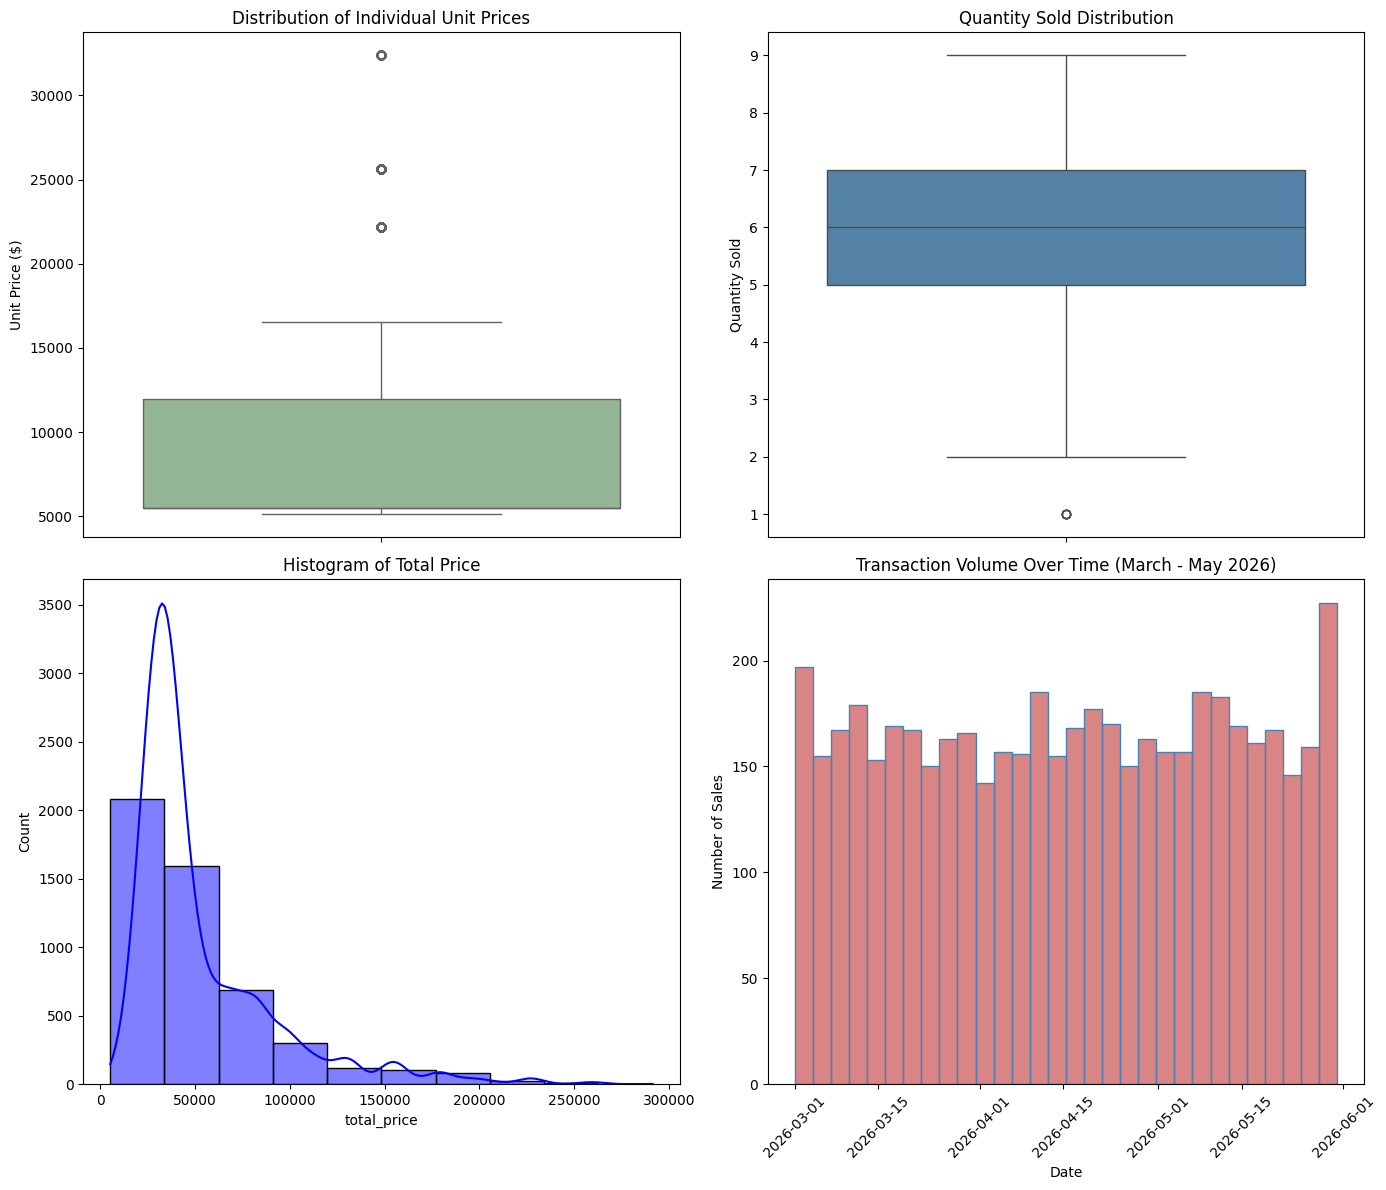

In [8]:
# Create a 2x2 grid for Sales Data Visualizations
fig, ax = plt.subplots(2, 2, figsize=(14, 12))

# 1. Top Left: Unit Price Boxplot (Translated from ggplot)
sns.boxplot(y=sales['unit_price'], ax=ax[0, 0], color='darkseagreen')
ax[0, 0].set_title("Distribution of Individual Unit Prices")
ax[0, 0].set_ylabel("Unit Price ($)")

# 2. Top Right: Quantity Sold Boxplot
sns.boxplot(y=sales['quantity_sold'], ax=ax[0, 1], color='steelblue')
ax[0, 1].set_title("Quantity Sold Distribution")
ax[0, 1].set_ylabel("Quantity Sold")

# 3. Bottom Left: Total Price Histogram (bins=10)
sns.histplot(sales['total_price'], bins=10, ax=ax[1, 0], kde=True, color='blue')
ax[1, 0].set_title("Histogram of Total Price")

# 4. Bottom Right: Transaction Volume Over Time (Date Histogram)
sns.histplot(sales['date'], bins=30, ax=ax[1, 1], color='indianred', edgecolor='steelblue')
ax[1, 1].set_title("Transaction Volume Over Time (March - May 2026)")
ax[1, 1].set_xlabel("Date")
ax[1, 1].set_ylabel("Number of Sales")

# Rotate date labels on the bottom right plot for better readability
plt.setp(ax[1, 1].get_xticklabels(), rotation=45)

# Final layout adjustment
plt.tight_layout()
plt.show()

###**4. Visualizations (7 points)**
This is an open-ended assignment. For this assignment you should develop **a minimum of five questions** that you would like to ask of the data.

Based on the questions that you develop, use appropriate data manipulation techniques and create appropriate visualizations to answer the questions. Use the tools we learned in class. **A minimum of five visualizations (graphs) must be provided.** This can include but not limited to: box plots, histograms, scatterplots, bar charts, column charts, line charts, pie charts, etc.

Provide **written commentary for each visualization** to explain how your selected visualizations answer the questions that you have developed. **A minimum of 2-3 sentences for each visualization.**

Note, your questions must be different from my final question, listed in number 5.


#Questions

1. How does car weight impact the highway fuel economy?
2. How does engine size impact horsepower and how does the number of cylinders factor in?
3. How do total car sales change over each day of the week?
4. What is the highest selling body style for the top 5 car brands?
5. Is there a specific unit priced vehicle range that sells the highest quantity?

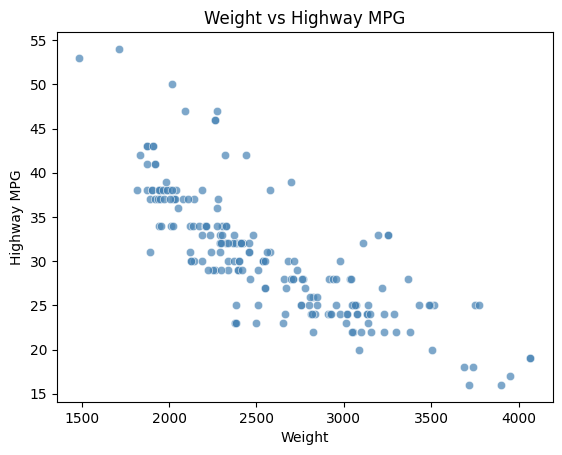

In [9]:
#1. How does car weight impact the highway fuel economy?
sns.scatterplot(
    data=automobiles,
    x=automobiles["curb_weight"],
    y=automobiles["highway_mpg"],
    color="steelblue",
    alpha=0.7)

plt.title("Weight vs Highway MPG")
plt.xlabel("Weight")
plt.ylabel("Highway MPG")

plt.show()

For Weight vs Highway MPG I wanted to see if a higher weight will result in worse fuel efficiency. My prediction seems to track as the scatterplot shows when the Weight increases the MPG decreases. Efficiency is directly tied to weight and this gives a negative relationship.


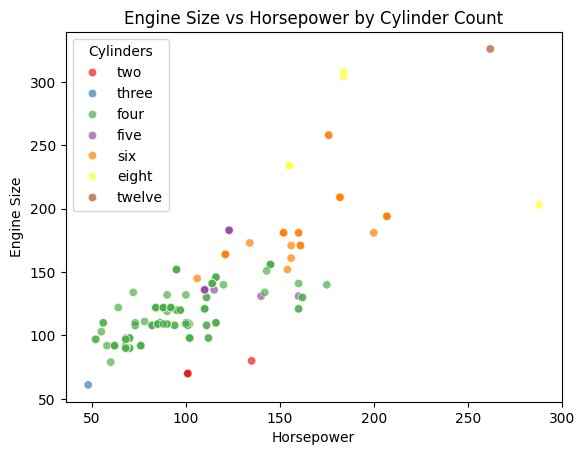

In [10]:
#2. How does engine size impact horsepower and how does the number of cylinders factor in?
sns.scatterplot(
    data=automobiles,
    x="horsepower",
    y="engine_size",
    hue="num_of_cylinders",
    palette="Set1",
    alpha=0.7)

plt.title("Engine Size vs Horsepower by Cylinder Count")
plt.xlabel("Horsepower")
plt.ylabel("Engine Size")
plt.legend(title="Cylinders")
plt.show()

The Engine Size vs Horsepower scatterplot shows a positive trend with higher Engine size directly relating to horsepower. This was expected as naturally more size would mean more room for parts to help increase that power. It's also interesting to see how cylinders affects it, There are many with four cylinders but the higher the count the higher the horsepower and engine size so they're all grouped similarly.

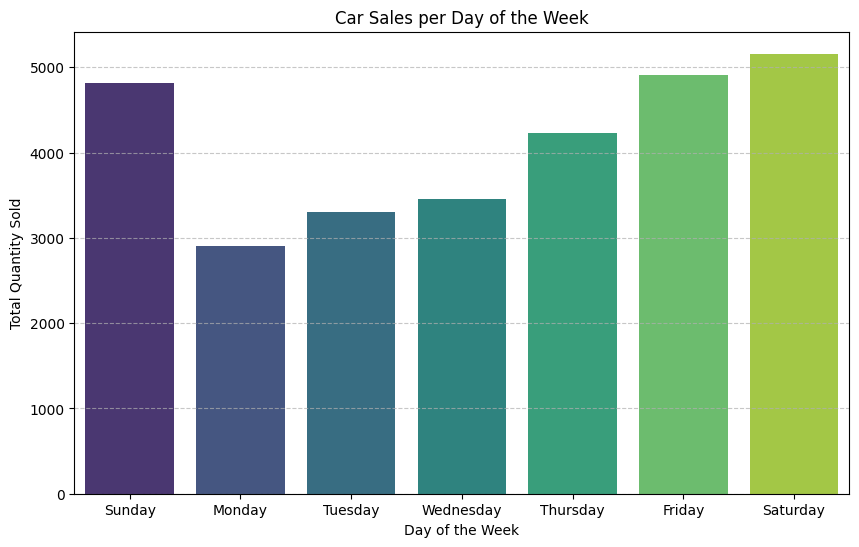

In [11]:
#3. How do total car sales change over each day of the week?

sales_per_day = sales.groupby('day', observed=False)['quantity_sold'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x='day',
    y='quantity_sold',
    data=sales_per_day,
    palette='viridis',
    hue='day',
    legend=False)

plt.title('Car Sales per Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Quantity Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

I was curious what day car sales are highest. This bar graph represents the total cars sold per day of the week. We can see that Saturday is the highest and Monday is the lowest which is unsurprising.

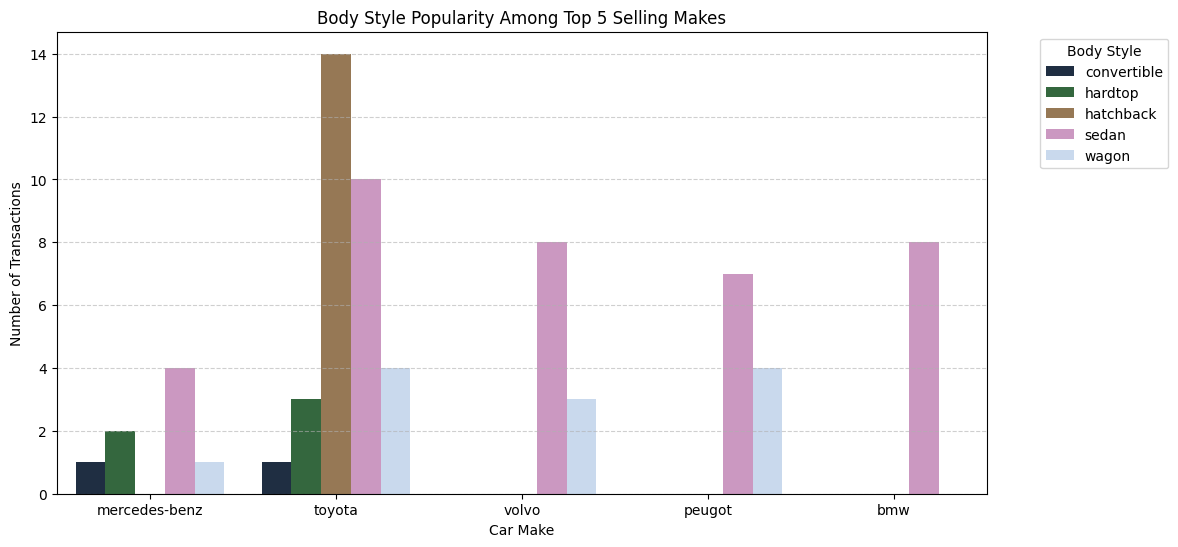

In [12]:
#4. What is the highest selling body style for the top 5 car brands

top_5_makes = top_10_selling_makes.head(5)['make'].tolist()
top_5_makes_specs = automobiles[automobiles['make'].isin(top_5_makes)]

plt.figure(figsize=(12, 6))
sns.countplot(
    data=top_5_makes_specs,
    x='make',
    hue='body_style',
    palette='cubehelix',
    order=top_5_makes)

plt.title('Body Style Popularity Among Top 5 Selling Makes')
plt.xlabel('Car Make')
plt.ylabel('Number of Transactions')
plt.legend(title='Body Style', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

This bar chart shows the body styles sold by each of the top 5 selling brands. Some brands like BMW are more specialized only having sedans while Toyota has some of everything. This is clearly working for Toyota as they're by far the highest seller.

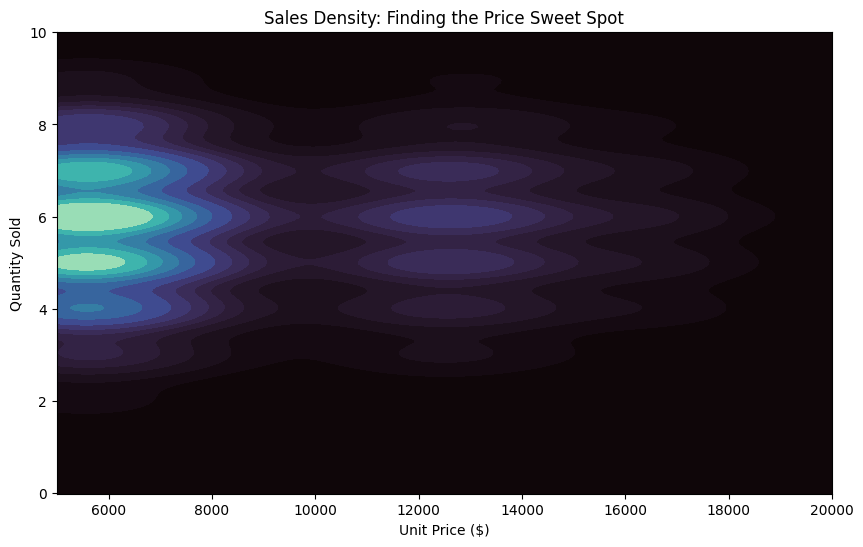

In [13]:
#5. Is there a specific unit priced vehicle range that sells the highest quantity?

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=sales,
    x='unit_price',
    y='quantity_sold',
    fill=True,
    thresh=0,
    levels=15,
    cmap="mako")

plt.xlim(5000, 20000)
plt.title('Sales Density: Finding the Price Sweet Spot')
plt.xlabel('Unit Price ($)')
plt.ylabel('Quantity Sold')

plt.show()

This is a heatmap to represent the density of sales at certain prices. There's a bright flash around 6000 dollars as it's easy to sell so many more of these lower cost cars. There another grouping around 12000-14000 dollars as these are also cheaper cars.

###**5. Final Questions (1 point)**

 Using the dataframes, determine which car type (make) generated the highest total revenue per unit of fuel efficiency on the highway during March, April, and May 2026. Calculate each car type's total revenue, compute its average highway MPG, and then create a new metric (variable):

Revenue Efficiency = Total Revenue / Average Highway MPG

Then, create a bar chart showing the top 10 car makes ranked by Revenue Efficiency. Display a visual to answer this question along with written commentary.

In [14]:
sales_filtered = sales[
    (sales["date"] >= "2026-03-01") &
    (sales["date"] <= "2026-05-31")]

# Join datasets (many-to-many equivalent)
combined = sales_filtered.merge(
    automobiles,
    on="make",
    how="left")

# Compute Revenue Efficiency
efficiency = combined.groupby("make").agg(
    total_revenue=("total_price", "sum"),
    avg_highway_mpg=("highway_mpg", "mean")
).reset_index()

efficiency["revenue_efficiency"] = (
    efficiency["total_revenue"] / efficiency["avg_highway_mpg"])

# Top 10 makes
top10 = efficiency.sort_values(
    by="revenue_efficiency",
    ascending=False)
print(sales.head(10))

        date       make body_style  quantity_sold    unit_price  \
0 2026-03-01        bmw      sedan              8  16541.040582   
1 2026-03-01     toyota  hatchback              8   5509.931436   
2 2026-03-01    porsche  hatchback              6  22159.524166   
3 2026-03-01    porsche  hatchback              5  22159.524166   
4 2026-03-01     subaru  hatchback              3   5289.036289   
5 2026-03-01      volvo      sedan              4  12895.394232   
6 2026-03-01      mazda  hatchback              7   5133.592832   
7 2026-03-01       saab  hatchback              6  11963.010500   
8 2026-03-01  chevrolet  hatchback              7   5245.191330   
9 2026-03-01     toyota  hatchback              6   5509.931436   

     total_price     day  
0  132328.324654  Sunday  
1   44079.451491  Sunday  
2  132957.144995  Sunday  
3  110797.620829  Sunday  
4   15867.108867  Sunday  
5   51581.576928  Sunday  
6   35935.149821  Sunday  
7   71778.063003  Sunday  
8   36716.339307  S

/tmp/ipykernel_7642/2343123998.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  efficiency = combined.groupby("make").agg(


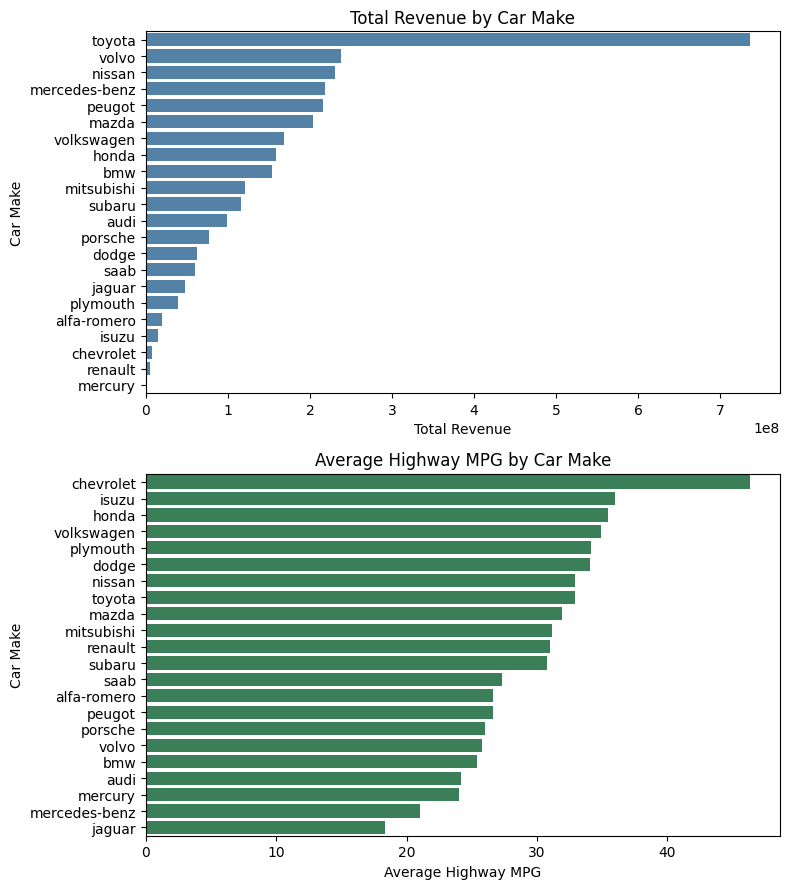

In [15]:
# Sort data
rev_sorted = efficiency.sort_values("total_revenue", ascending=False)
mpg_sorted = efficiency.sort_values("avg_highway_mpg", ascending=False)
top10_sorted = top10.sort_values("revenue_efficiency", ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# 1. Total Revenue
sns.barplot(
    data=rev_sorted,
    x="total_revenue",
    y="make",
    order=rev_sorted["make"],
    color="steelblue",
    ax=axes[0])
axes[0].set_title("Total Revenue by Car Make")
axes[0].set_xlabel("Total Revenue")
axes[0].set_ylabel("Car Make")

# 2. Average Highway MPG
sns.barplot(
    data=mpg_sorted,
    x="avg_highway_mpg",
    y="make",
    order=mpg_sorted["make"],
    color="seagreen",
    ax=axes[1])
axes[1].set_title("Average Highway MPG by Car Make")
axes[1].set_xlabel("Average Highway MPG")
axes[1].set_ylabel("Car Make")

plt.tight_layout()
plt.show()

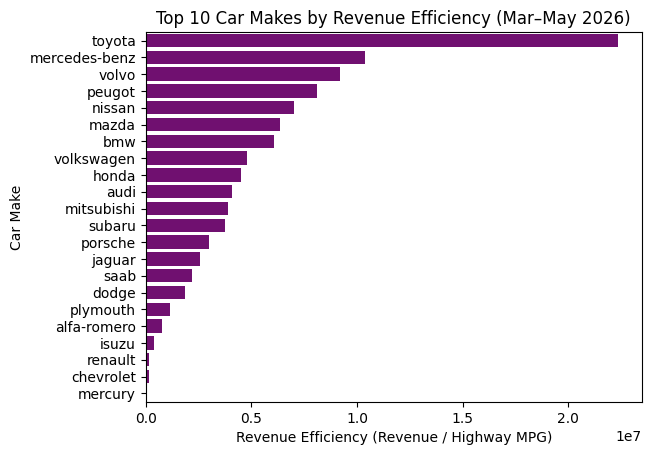

In [16]:
# 3. Revenue Efficiency
sns.barplot(
    data=top10_sorted,
    x="revenue_efficiency",
    y="make",
    order=top10_sorted["make"],
    color="purple")
plt.title("Top 10 Car Makes by Revenue Efficiency (Mar–May 2026)")
plt.xlabel("Revenue Efficiency (Revenue / Highway MPG)")
plt.ylabel("Car Make")

plt.show()

This visual ranks each car manufacturer on their revenue efficiency. This is the measure of total revenue generated over the average highway fuel efficiency. It combines profitability and fuel usage to find who performs well financially and ranks them according. We can see Toyota is easily the leader but this is actually because of their total revenue, They have about a 400,000,000 dollar lead on the next competitor and this makes them unbeatable regardless of their highway mpg which is 7th.

### **Submission**

To submit your work, you need to print your Notebook. First, go to the "Runtime" menu and click "Run all". This will ensure that all code in your Notebook has been executed (and that you code runs correctly).  

Follow the commands listed below to save project as a pdf.

File-> Print-> Save As PDF (or similar)-> More Settings-> Background Graphics (selected)-> Save

Once the project is saved as a pdf, upload the pdf as your Canvas assignment submission. You can also share the link to your project to ensure all items are visible.
